<a href="https://www.kaggle.com/code/metisa81/max-auxetic-ml-t4-safe?scriptVersionId=346803128" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# MAX Auxetic ML — Paper-Ready Validation & Mechanism Analysis

## هدف
این نسخه بر اساس نتایج نسخه قبلی ساخته شده و تمرکز آن روی سؤال اصلی پروژه است:

1. آیا ترکیب شیمیایی به‌تنهایی می‌تواند Auxetic بودن را تشخیص دهد؟
2. آیا مدل مواد Auxetic شدید را بهتر از موارد نزدیک صفر تشخیص می‌دهد؟
3. کدام مواد از دست می‌روند و چرا؟
4. آیا نتیجه در اعتبارسنجی سخت‌تر بر اساس عنصر M پایدار می‌ماند؟
5. آیا ویژگی‌های شیمیایی با روندهای فیزیکی شناخته‌شده برای Auxeticity سازگارند؟

**نکته مهم:** مدل Chemical-only هیچ Cij یا Poisson target را به عنوان feature نمی‌بیند.


In [21]:
# ============================================================
# 0. Install / Imports
# ============================================================
!pip install -q xgboost scikit-learn pandas matplotlib seaborn

import re
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from xgboost import XGBClassifier, XGBRegressor

from sklearn.model_selection import (
    StratifiedKFold, KFold, GroupKFold,
    RandomizedSearchCV, cross_val_predict
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    mean_absolute_error, mean_squared_error, r2_score,
    precision_recall_curve, roc_curve
)
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
N_JOBS_MODEL = 2
N_JOBS_SEARCH = 1

DATA_DIR = "/kaggle/input/datasets/metisa81/elastic-properties"
OUT_DIR = "/kaggle/working"

print("✓ Environment ready")
print("XGBoost device: CPU")


✓ Environment ready
XGBoost device: CPU


## 1. ساخت دیتاست

همان منطق نسخه قبلی حفظ شده است:
- ترکیب واقعی از نام ماده استخراج می‌شود.
- POSCAR هندسی استفاده نمی‌شود، چون template مشترک و unrelaxed است.
- فقط مواد Mechanical Stable با Min/Max پواسون موجود وارد می‌شوند.


In [22]:
# ============================================================
# 1. Load VASPKIT + periodic table
# ============================================================
def parse_formula(name):
    tokens = re.findall(r'[A-Z][a-z]?', name)
    if len(tokens) != 3:
        raise ValueError(f"Unexpected formula: {name} -> {tokens}")
    return tokens  # M, A, X

with open(f"{DATA_DIR}/vaspkit_output.json", "r") as f:
    vk = json.load(f)

ptable = pd.read_csv(f"{DATA_DIR}/ptable2.csv").set_index("symbol")

ELEMENT_COLS = [
    'atomic_number','atomic_radius','covalent_radius_cordero',
    'atomic_weight','density','melting_point','boiling_point',
    'en_pauling','electron_affinity','ionization_energy',
    'valance_main','group_id','period','dipole_polarizability',
    'atomic_volume','vdw_radius'
]

rows, skipped = [], []

for name, d in tqdm(vk.items(), desc="Building dataset"):
    stability = d.get("Additional_Properties", {}).get("Mechanical_Stability")
    if stability != "Stable":
        continue

    aniso = d.get("Anisotropic_Mechanical_Properties", {}).get("Poisson's_Ratio_v")
    if not isinstance(aniso, dict) or "Min" not in aniso or "Max" not in aniso:
        skipped.append((name, "missing anisotropic Poisson"))
        continue

    try:
        m, a, x = parse_formula(name)
        if any(el not in ptable.index for el in (m, a, x)):
            skipped.append((name, "element missing in ptable"))
            continue

        row = {"material": name, "M": m, "A": a, "X": x}

        for site, el in [('M', m), ('A', a), ('X', x)]:
            props = ptable.loc[el, ELEMENT_COLS]
            for c in ELEMENT_COLS:
                row[f"{site}_{c}"] = props[c]

        row["en_diff_MX"] = ptable.loc[m, "en_pauling"] - ptable.loc[x, "en_pauling"]
        row["en_diff_MA"] = ptable.loc[m, "en_pauling"] - ptable.loc[a, "en_pauling"]
        row["radius_ratio_AX"] = (
            ptable.loc[a, "covalent_radius_cordero"] /
            ptable.loc[x, "covalent_radius_cordero"]
        )

        row["M_enpauling_x_Mgroup"] = row["M_en_pauling"] * row["M_group_id"]
        row["M_ionize_x_A_valance"] = row["M_ionization_energy"] * row["A_valance_main"]
        row["endiffMX_x_radiusratio"] = row["en_diff_MX"] * row["radius_ratio_AX"]
        row["Mgroup_x_Agroup"] = row["M_group_id"] * row["A_group_id"]
        row["Menpauling_x_Aenpauling"] = row["M_en_pauling"] * row["A_en_pauling"]

        row["VEC"] = (
            2 * row["M_group_id"] +
            row["A_valance_main"] +
            row["X_valance_main"]
        ) / 4

        row["VEC_x_endiffMX"] = row["VEC"] * row["en_diff_MX"]

        row["Aniso_Poisson_Min"] = float(aniso["Min"])
        row["Aniso_Poisson_Max"] = float(aniso["Max"])

        rows.append(row)
    except Exception as e:
        skipped.append((name, str(e)))

df = pd.DataFrame(rows).set_index("material")

FEATURE_COLS = [
    c for c in df.columns
    if c.startswith(("M_", "A_", "X_"))
    or c in [
        "en_diff_MX", "en_diff_MA", "radius_ratio_AX",
        "M_enpauling_x_Mgroup", "M_ionize_x_A_valance",
        "endiffMX_x_radiusratio", "Mgroup_x_Agroup",
        "Menpauling_x_Aenpauling", "VEC", "VEC_x_endiffMX"
    ]
]

y_reg = df["Aniso_Poisson_Min"].values
y_class = (y_reg < 0).astype(int)

print("="*70)
print(f"Final materials: {len(df)}")
print(f"Features: {len(FEATURE_COLS)}")
print(f"Auxetic: {y_class.sum()} / {len(df)} = {y_class.mean()*100:.2f}%")
print(f"Skipped: {len(skipped)}")
print("="*70)


Building dataset:   0%|          | 0/553 [00:00<?, ?it/s]

Final materials: 547
Features: 58
Auxetic: 134 / 547 = 24.50%
Skipped: 1


## 2. کنترل توزیع و تعریف Auxetic شدید

برای این نسخه فقط مرز اصلی **νmin < 0** معیار Auxetic است.

برای تحلیل خطا، علاوه بر آن سه ناحیه بررسی می‌شود:
- Near-zero: `-0.05 ≤ νmin < 0`
- Moderate: `-0.20 ≤ νmin < -0.05`
- Strong: `νmin < -0.20`

این دسته‌بندی صرفاً برای تحلیل خطا است و تعریف اصلی Auxetic را تغییر نمی‌دهد.


count    547.000000
mean       0.060720
std        0.230301
min       -3.079000
25%        0.002000
50%        0.109000
75%        0.177500
max        0.312000
Name: Aniso_Poisson_Min, dtype: float64

Severity counts:
Normal               413
Moderate auxetic      73
Near-zero auxetic     33
Strong auxetic        28
Name: count, dtype: int64


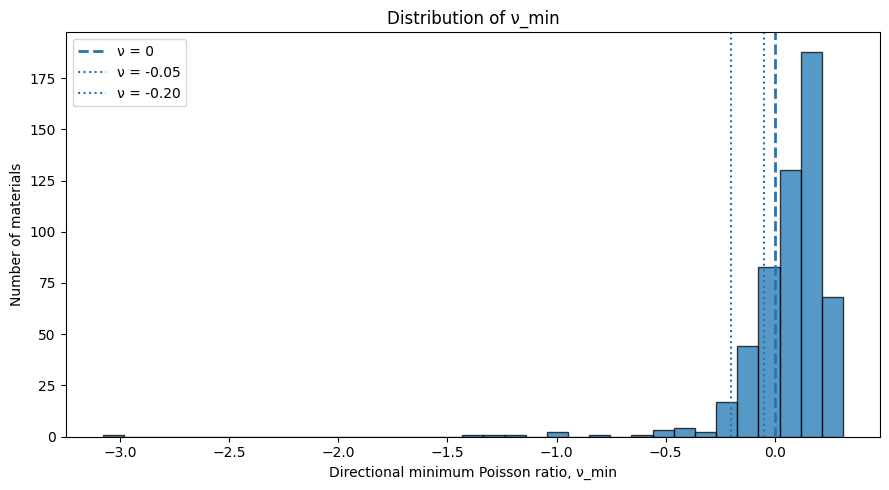

In [23]:
# ============================================================
# 2. Target distribution + severity groups
# ============================================================
severity = pd.Series(index=df.index, dtype="object")
severity[y_reg >= 0] = "Normal"
severity[(y_reg < 0) & (y_reg >= -0.05)] = "Near-zero auxetic"
severity[(y_reg < -0.05) & (y_reg >= -0.20)] = "Moderate auxetic"
severity[y_reg < -0.20] = "Strong auxetic"

print(df["Aniso_Poisson_Min"].describe())
print("\nSeverity counts:")
print(severity.value_counts())

fig, ax = plt.subplots(figsize=(9,5))
ax.hist(y_reg, bins=35, edgecolor="black", alpha=0.75)
ax.axvline(0, linestyle="--", linewidth=2, label="ν = 0")
ax.axvline(-0.05, linestyle=":", linewidth=1.5, label="ν = -0.05")
ax.axvline(-0.20, linestyle=":", linewidth=1.5, label="ν = -0.20")
ax.set_xlabel("Directional minimum Poisson ratio, ν_min")
ax.set_ylabel("Number of materials")
ax.set_title("Distribution of ν_min")
ax.legend()
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/01_target_distribution.png", dpi=220)
plt.show()


## 3. حذف leakage و بررسی تکراری بودن ترکیب‌ها

این بخش برای مقاله مهم است. اگر یک فرمول چند بار در داده وجود داشته باشد، باید مطمئن شویم نمونه‌های تکراری باعث خوش‌بینی مدل نشده‌اند.


In [24]:
# ============================================================
# 3. Leakage + duplicate composition check
# ============================================================
X = df[FEATURE_COLS].copy()

FORBIDDEN = [
    "Aniso_Poisson_Min", "Aniso_Poisson_Max",
    "C11", "C12", "C13", "C33", "C44", "C66"
]

leak_cols = [c for c in X.columns if c in FORBIDDEN]
assert len(leak_cols) == 0, f"LEAKAGE DETECTED: {leak_cols}"

formula_key = df["M"] + "2" + df["A"] + df["X"]
duplicate_mask = formula_key.duplicated(keep=False)

print(f"X shape = {X.shape}")
print("✓ No Poisson/Cij target leakage")
print(f"Unique compositions: {formula_key.nunique()}")
print(f"Rows in duplicated composition groups: {duplicate_mask.sum()}")

if duplicate_mask.sum():
    print("\nDuplicated formulas:")
    print(pd.DataFrame({"formula": formula_key[duplicate_mask]}).value_counts().head(20))


X shape = (547, 58)
✓ No Poisson/Cij target leakage
Unique compositions: 547
Rows in duplicated composition groups: 0


## 4. مدل اصلی Classification

این مدل فقط با ویژگی‌های شیمیایی آموزش می‌بیند.

معیار اصلی برای Auxetic:
**F1 + Recall + PR-AUC**

Accuracy به تنهایی کافی نیست، چون کلاس Auxetic فقط حدود یک‌چهارم داده است.


In [25]:
# ============================================================
# 4. Chemical-only XGBoost classifier
# ============================================================
skf = StratifiedKFold(
    n_splits=5, shuffle=True, random_state=RANDOM_STATE
)

param_dist_clf = {
    "n_estimators": [150, 250, 350, 500, 700],
    "max_depth": [2, 3, 4, 5],
    "learning_rate": [0.015, 0.03, 0.05, 0.08, 0.12],
    "subsample": [0.65, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.75, 0.9, 1.0],
    "min_child_weight": [1, 2, 4, 6],
    "gamma": [0, 0.05, 0.1, 0.2],
    "reg_alpha": [0, 0.01, 0.1, 0.5],
    "reg_lambda": [0.8, 1.0, 1.5, 2.0, 3.0]
}

base_clf = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    device="cpu",
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS_MODEL
)

search_clf = RandomizedSearchCV(
    base_clf,
    param_distributions=param_dist_clf,
    n_iter=30,
    scoring="f1",
    cv=skf,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS_SEARCH,
    refit=True
)

search_clf.fit(X, y_class)
best_clf = search_clf.best_estimator_

oof_class = cross_val_predict(
    best_clf, X, y_class,
    cv=skf, method="predict", n_jobs=N_JOBS_SEARCH
)
oof_prob = cross_val_predict(
    best_clf, X, y_class,
    cv=skf, method="predict_proba", n_jobs=N_JOBS_SEARCH
)[:,1]

metrics_clf = {
    "Accuracy": accuracy_score(y_class, oof_class),
    "Precision": precision_score(y_class, oof_class, zero_division=0),
    "Recall": recall_score(y_class, oof_class, zero_division=0),
    "F1": f1_score(y_class, oof_class, zero_division=0),
    "ROC-AUC": roc_auc_score(y_class, oof_prob),
    "PR-AUC": average_precision_score(y_class, oof_prob)
}

print("Best parameters:")
print(search_clf.best_params_)
print("\nOOF classification:")
for k,v in metrics_clf.items():
    print(f"{k:10s}: {v:.4f}")

print("\nClassification report:")
print(classification_report(
    y_class, oof_class,
    target_names=["Normal","Auxetic"],
    zero_division=0
))


Best parameters:
{'subsample': 1.0, 'reg_lambda': 2.0, 'reg_alpha': 0.1, 'n_estimators': 250, 'min_child_weight': 4, 'max_depth': 5, 'learning_rate': 0.12, 'gamma': 0.05, 'colsample_bytree': 0.75}

OOF classification:
Accuracy  : 0.8574
Precision : 0.7545
Recall    : 0.6194
F1        : 0.6803
ROC-AUC   : 0.8404
PR-AUC    : 0.7286

Classification report:
              precision    recall  f1-score   support

      Normal       0.88      0.93      0.91       413
     Auxetic       0.75      0.62      0.68       134

    accuracy                           0.86       547
   macro avg       0.82      0.78      0.79       547
weighted avg       0.85      0.86      0.85       547



## 5. Threshold analysis

در نسخه قبلی آستانه 0.5 استفاده شد. این الزام علمی ندارد.

چون هدف پژوهش **پیدا کردن Auxeticها** است، بررسی می‌کنیم آیا با تغییر threshold می‌توان Recall را بالا برد، بدون اینکه Precision کاملاً خراب شود.

برای مقاله، threshold باید فقط روی داده validation تعیین شود، نه با نگاه کردن به test نهایی.


,threshold,precision,recall,f1,accuracy
0,0.10,0.448276,0.776119,0.568306,0.711152
1,0.15,0.502564,0.731343,0.595745,0.756856
2,0.20,0.552941,0.701493,0.618421,0.787934
3,0.25,0.620000,0.694030,0.654930,0.820841
4,0.30,0.645390,0.679104,0.661818,0.829982
5,0.35,0.687023,0.671642,0.679245,0.844607
6,0.40,0.701613,0.649254,0.674419,0.846435
7,0.45,0.736842,0.626866,0.677419,0.853748
8,0.50,0.754545,0.619403,0.680328,0.857404
9,0.55,0.769231,0.597015,0.672269,0.857404



Best OOF F1 threshold:
threshold    0.500000
precision    0.754545
recall       0.619403
f1           0.680328
accuracy     0.857404
Name: 8, dtype: float64


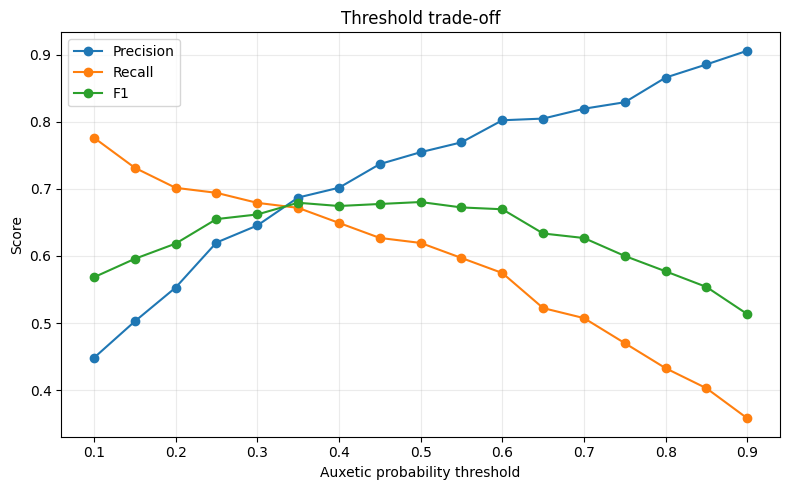

In [26]:
# ============================================================
# 5. Threshold analysis
# ============================================================
threshold_rows = []

for t in np.arange(0.10, 0.91, 0.05):
    pred = (oof_prob >= t).astype(int)
    threshold_rows.append({
        "threshold": round(float(t),2),
        "precision": precision_score(y_class, pred, zero_division=0),
        "recall": recall_score(y_class, pred, zero_division=0),
        "f1": f1_score(y_class, pred, zero_division=0),
        "accuracy": accuracy_score(y_class, pred)
    })

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df)

best_f1_row = threshold_df.loc[threshold_df["f1"].idxmax()]
print("\nBest OOF F1 threshold:")
print(best_f1_row)

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="Precision")
ax.plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="Recall")
ax.plot(threshold_df["threshold"], threshold_df["f1"], marker="o", label="F1")
ax.set_xlabel("Auxetic probability threshold")
ax.set_ylabel("Score")
ax.set_title("Threshold trade-off")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/02_threshold_analysis.png", dpi=220)
plt.show()


## 6. بررسی دقیق Confusion Matrix

اینجا مشخص می‌شود چند Auxetic واقعاً پیدا شده و چند مورد از دست رفته است.


Confusion matrix:
[[386  27]
 [ 51  83]]
True negatives : 386
False positives: 27
False negatives: 51
True positives : 83


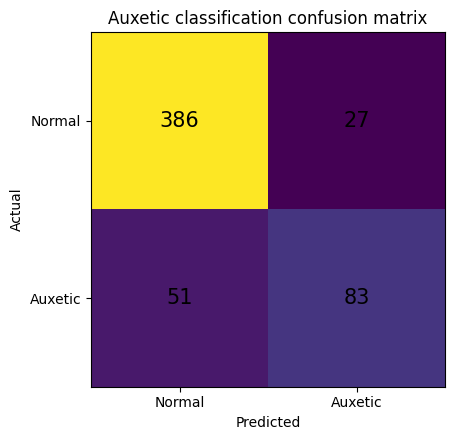

In [27]:
# ============================================================
# 6. Confusion matrix
# ============================================================
cm = confusion_matrix(y_class, oof_class)
tn, fp, fn, tp = cm.ravel()

print("Confusion matrix:")
print(cm)
print(f"True negatives : {tn}")
print(f"False positives: {fp}")
print(f"False negatives: {fn}")
print(f"True positives : {tp}")

fig, ax = plt.subplots(figsize=(5,4.5))
im = ax.imshow(cm)
ax.set_xticks([0,1], ["Normal","Auxetic"])
ax.set_yticks([0,1], ["Normal","Auxetic"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Auxetic classification confusion matrix")
for i in range(2):
    for j in range(2):
        ax.text(j,i,cm[i,j],ha="center",va="center",fontsize=15)
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/03_confusion_matrix.png", dpi=220)
plt.show()


## 7. آیا مدل Auxeticهای شدید را بهتر می‌شناسد؟

این یکی از مهم‌ترین تحلیل‌های علمی نسخه جدید است.

برای هر Auxetic، خطای مطلق و احتمال Auxetic بررسی می‌شود.
اگر مدل برای Auxeticهای شدید عملکرد بهتری داشته باشد، این می‌تواند نشان دهد که chemistry descriptors یک signal واقعی از مکانیزم دارند و مدل فقط موارد نزدیک صفر را شکار نمی‌کند.


Auxetic probability by severity:
                   count      mean    median       min       max
severity                                                        
Moderate auxetic      73  0.533839  0.628680  0.001931  0.997555
Near-zero auxetic     33  0.629344  0.781352  0.018493  0.995389
Strong auxetic        28  0.637470  0.868341  0.002175  0.998558

Recall by severity:
Near-zero auxetic   : n= 33, detected= 24, recall=0.727
Moderate auxetic    : n= 73, detected= 41, recall=0.562
Strong auxetic      : n= 28, detected= 18, recall=0.643


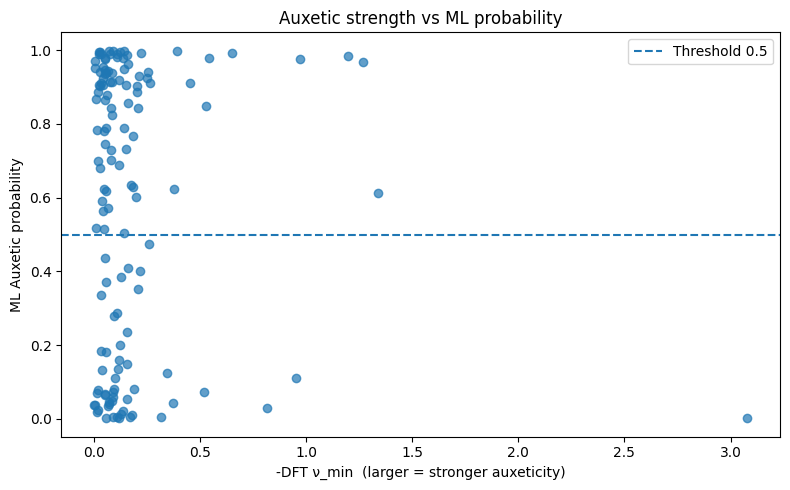

In [28]:
# ============================================================
# 7. Auxetic severity analysis
# ============================================================
results = pd.DataFrame({
    "material": df.index,
    "M": df["M"].values,
    "A": df["A"].values,
    "X": df["X"].values,
    "DFT_nu_min": y_reg,
    "ML_nu_min": np.nan,
    "ML_auxetic_probability": oof_prob,
    "Actual_Auxetic": y_class,
    "Predicted_Auxetic": oof_class
}).set_index("material")

# regression predictions are filled later
results["severity"] = severity
results["abs_class_margin"] = np.abs(oof_prob - 0.5)

print("Auxetic probability by severity:")
print(
    results[results["Actual_Auxetic"]==1]
    .groupby("severity")["ML_auxetic_probability"]
    .agg(["count","mean","median","min","max"])
)

print("\nRecall by severity:")
for group in ["Near-zero auxetic","Moderate auxetic","Strong auxetic"]:
    sub = results[results["severity"]==group]
    if len(sub):
        print(
            f"{group:20s}: n={len(sub):3d}, "
            f"detected={sub['Predicted_Auxetic'].sum():3d}, "
            f"recall={sub['Predicted_Auxetic'].mean():.3f}"
        )

fig, ax = plt.subplots(figsize=(8,5))
aux = results[results["Actual_Auxetic"]==1]
ax.scatter(-aux["DFT_nu_min"], aux["ML_auxetic_probability"], alpha=0.7)
ax.axhline(0.5, linestyle="--", label="Threshold 0.5")
ax.set_xlabel("-DFT ν_min  (larger = stronger auxeticity)")
ax.set_ylabel("ML Auxetic probability")
ax.set_title("Auxetic strength vs ML probability")
ax.legend()
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/04_auxetic_strength_probability.png", dpi=220)
plt.show()


## 8. رگرسیون مستقیم νmin

این بخش جدا از classification است.

هدف آن پیش‌بینی مقدار عددی νmin است، اما انتظار نداریم composition-only به اندازه مدل مبتنی بر Cij دقیق باشد.


In [29]:
# ============================================================
# 8. Direct regression
# ============================================================
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

param_dist_reg = {
    "n_estimators": [150, 250, 350, 500, 700],
    "max_depth": [2,3,4,5],
    "learning_rate": [0.015,0.03,0.05,0.08,0.12],
    "subsample": [0.65,0.8,0.9,1.0],
    "colsample_bytree": [0.6,0.75,0.9,1.0],
    "min_child_weight": [1,2,4,6],
    "gamma": [0,0.05,0.1,0.2],
    "reg_alpha": [0,0.01,0.1,0.5],
    "reg_lambda": [0.8,1.0,1.5,2.0,3.0]
}

base_reg = XGBRegressor(
    objective="reg:squarederror",
    eval_metric="mae",
    tree_method="hist",
    device="cpu",
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS_MODEL
)

search_reg = RandomizedSearchCV(
    base_reg,
    param_distributions=param_dist_reg,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=kf,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS_SEARCH,
    refit=True
)

search_reg.fit(X, y_reg)
best_reg = search_reg.best_estimator_

oof_reg = cross_val_predict(
    best_reg, X, y_reg,
    cv=kf, method="predict", n_jobs=N_JOBS_SEARCH
)

mae = mean_absolute_error(y_reg, oof_reg)
rmse = np.sqrt(mean_squared_error(y_reg, oof_reg))
r2 = r2_score(y_reg, oof_reg)

print("Best parameters:")
print(search_reg.best_params_)
print("\nOOF regression:")
print(f"MAE : {mae:.5f}")
print(f"RMSE: {rmse:.5f}")
print(f"R²  : {r2:.5f}")

results["ML_nu_min"] = oof_reg
results["ML_auxetic_by_regression"] = oof_reg < 0
results["absolute_error"] = np.abs(y_reg - oof_reg)


Best parameters:
{'subsample': 1.0, 'reg_lambda': 1.0, 'reg_alpha': 0.5, 'n_estimators': 150, 'min_child_weight': 6, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.75}

OOF regression:
MAE : 0.10126
RMSE: 0.21756
R²  : 0.10598


## 9. مهم‌ترین تست: آیا رگرسیون واقعاً علامت منفی را پیدا می‌کند؟


In [30]:
# ============================================================
# 9. Regression sign test
# ============================================================
actual_aux = y_reg < 0
pred_aux_reg = oof_reg < 0

print("===== DIRECT REGRESSION SIGN TEST =====")
print(f"Actual auxetic      : {actual_aux.sum()}")
print(f"Predicted negative  : {pred_aux_reg.sum()}")
print(f"Correct negative    : {(actual_aux & pred_aux_reg).sum()}")
print(f"Missed auxetic      : {(actual_aux & ~pred_aux_reg).sum()}")
print(f"False negative pred.: {(~actual_aux & pred_aux_reg).sum()}")

print("\nClassification from regression sign:")
print(f"Accuracy : {accuracy_score(actual_aux, pred_aux_reg):.4f}")
print(f"Precision: {precision_score(actual_aux, pred_aux_reg, zero_division=0):.4f}")
print(f"Recall   : {recall_score(actual_aux, pred_aux_reg, zero_division=0):.4f}")
print(f"F1       : {f1_score(actual_aux, pred_aux_reg, zero_division=0):.4f}")


===== DIRECT REGRESSION SIGN TEST =====
Actual auxetic      : 134
Predicted negative  : 127
Correct negative    : 83
Missed auxetic      : 51
False negative pred.: 44

Classification from regression sign:
Accuracy : 0.8263
Precision: 0.6535
Recall   : 0.6194
F1       : 0.6360


## 10. Parity plot و تحلیل خطا

نقاط Auxetic با رنگ/marker جداگانه نمایش داده می‌شوند تا ببینیم مدل در اطراف مرز ν=0 چه رفتاری دارد.


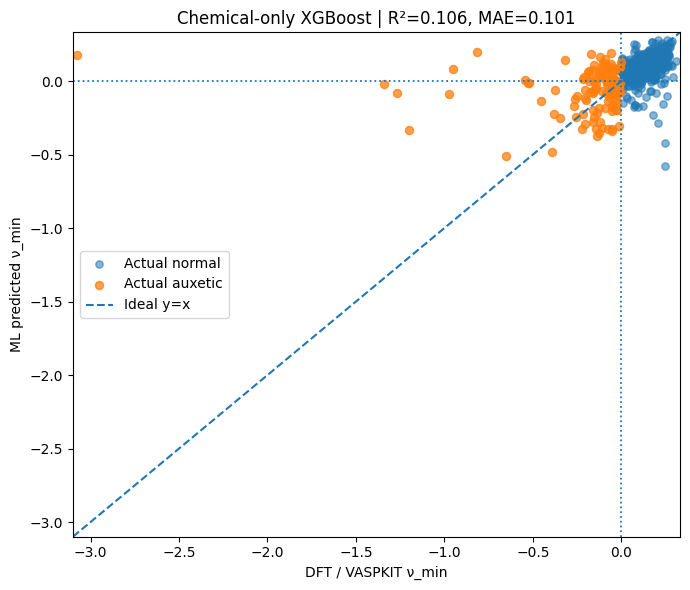


Worst Auxetic regression errors:
           M   A   X  DFT_nu_min  ML_nu_min  ML_auxetic_probability  \
material                                                              
Mo2SnN    Mo  Sn   N      -3.079   0.179677                0.002175   
Hf2ZnS    Hf  Zn   S      -1.340  -0.019050                0.613974   
Zr2SnP    Zr  Sn   P      -1.269  -0.083910                0.967606   
V2SnN      V  Sn   N      -0.952   0.079933                0.111472   
Cr2PN     Cr   P   N      -0.816   0.198712                0.029218   
Sc2SbSi   Sc  Sb  Si      -0.973  -0.086134                0.977412   
Hf2GeP    Hf  Ge   P      -1.199  -0.334726                0.985116   
Sc2BiP    Sc  Bi   P      -0.544   0.007077                0.979935   
Ta2GeB    Ta  Ge   B      -0.528  -0.011484                0.849357   
Sc2SiS    Sc  Si   S      -0.520  -0.010128                0.072932   
Ti2IrB    Ti  Ir   B      -0.319   0.142895                0.006156   
V2CdC      V  Cd   C      -0.172   0.181376

In [31]:
# ============================================================
# 10. Parity plot
# ============================================================
fig, ax = plt.subplots(figsize=(7,6))

normal = y_reg >= 0
aux = y_reg < 0

ax.scatter(y_reg[normal], oof_reg[normal], alpha=0.55, s=28, label="Actual normal")
ax.scatter(y_reg[aux], oof_reg[aux], alpha=0.75, s=34, label="Actual auxetic")

lims = [
    min(y_reg.min(), oof_reg.min()) - 0.02,
    max(y_reg.max(), oof_reg.max()) + 0.02
]
ax.plot(lims, lims, "--", linewidth=1.5, label="Ideal y=x")
ax.axhline(0, linestyle=":", linewidth=1.3)
ax.axvline(0, linestyle=":", linewidth=1.3)

ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("DFT / VASPKIT ν_min")
ax.set_ylabel("ML predicted ν_min")
ax.set_title(f"Chemical-only XGBoost | R²={r2:.3f}, MAE={mae:.3f}")
ax.legend()
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/05_poisson_parity.png", dpi=240)
plt.show()

print("\nWorst Auxetic regression errors:")
print(
    results[results["Actual_Auxetic"]==1]
    .sort_values("absolute_error", ascending=False)
    [["M","A","X","DFT_nu_min","ML_nu_min","ML_auxetic_probability","absolute_error"]]
    .head(20)
)


## 11. اعتبارسنجی سخت‌تر: GroupKFold بر اساس M

در این آزمایش یک عنصر M نمی‌تواند همزمان در train و test باشد.

این تست برای بررسی generalization به فلز انتقالی دیده‌نشده مهم است.


In [32]:
# ============================================================
# 11. GroupKFold by M
# ============================================================
groups_M = df["M"].values
n_groups = df["M"].nunique()

print(f"Unique M elements: {n_groups}")

if n_groups >= 5:
    gkf = GroupKFold(n_splits=5)

    group_clf = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        device="cpu",
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS_MODEL,
        **search_clf.best_params_
    )

    group_pred = cross_val_predict(
        group_clf, X, y_class,
        cv=gkf, groups=groups_M,
        method="predict", n_jobs=N_JOBS_SEARCH
    )

    print("===== GROUP-CV BY M =====")
    print(f"Accuracy : {accuracy_score(y_class, group_pred):.4f}")
    print(f"Precision: {precision_score(y_class, group_pred, zero_division=0):.4f}")
    print(f"Recall   : {recall_score(y_class, group_pred, zero_division=0):.4f}")
    print(f"F1       : {f1_score(y_class, group_pred, zero_division=0):.4f}")

    group_prob = cross_val_predict(
        group_clf, X, y_class,
        cv=gkf, groups=groups_M,
        method="predict_proba", n_jobs=N_JOBS_SEARCH
    )[:,1]

    print(f"ROC-AUC  : {roc_auc_score(y_class, group_prob):.4f}")
    print(f"PR-AUC   : {average_precision_score(y_class, group_prob):.4f}")
else:
    print("Not enough M groups.")


Unique M elements: 17
===== GROUP-CV BY M =====
Accuracy : 0.8355
Precision: 0.7115
Recall   : 0.5522
F1       : 0.6218
ROC-AUC  : 0.8225
PR-AUC   : 0.7140


## 12. Feature importance + permutation importance

Tree importance برای تفسیر اولیه استفاده می‌شود.

برای تفسیر قوی‌تر، permutation importance نیز روی OOF-like split محاسبه می‌شود.
**Importance به‌تنهایی رابطه علّی را اثبات نمی‌کند.**


Top 25 XGBoost features:


M_melting_point              0.128910
X_atomic_number              0.092909
radius_ratio_AX              0.050724
A_group_id                   0.041212
Mgroup_x_Agroup              0.037161
A_valance_main               0.031952
M_ionize_x_A_valance         0.029545
X_ionization_energy          0.027388
VEC                          0.024262
X_atomic_weight              0.020913
X_atomic_volume              0.020638
X_atomic_radius              0.019993
M_atomic_radius              0.019392
X_valance_main               0.018560
M_atomic_number              0.017270
A_vdw_radius                 0.016963
A_en_pauling                 0.016871
M_density                    0.015883
A_atomic_weight              0.015570
A_ionization_energy          0.015433
A_density                    0.015333
A_covalent_radius_cordero    0.014666
A_electron_affinity          0.014644
M_en_pauling                 0.014526
M_covalent_radius_cordero    0.014444
dtype: float32

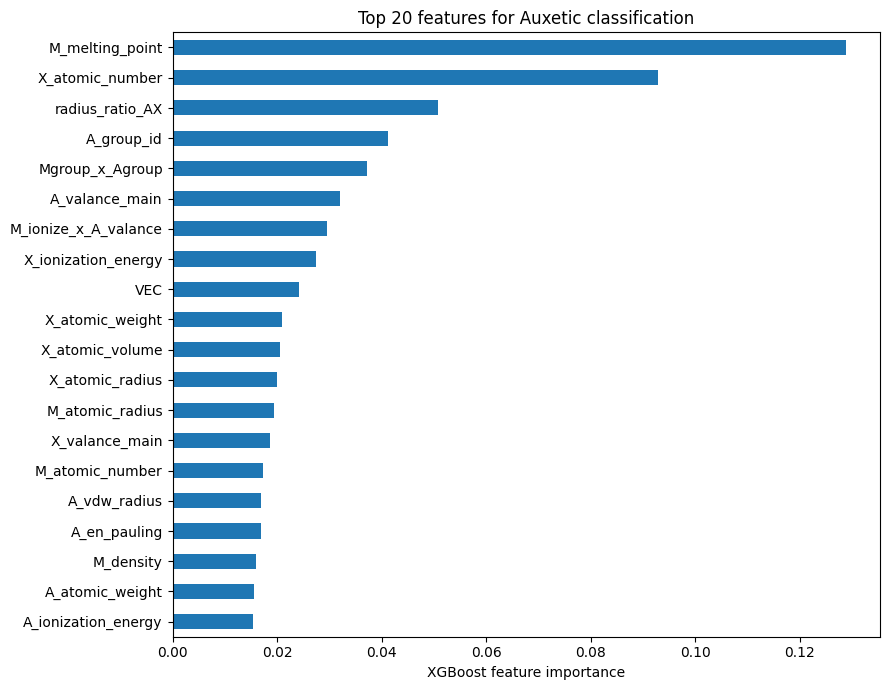

In [33]:
# ============================================================
# 12. Feature importance
# ============================================================
clf_final = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    device="cpu",
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS_MODEL,
    **search_clf.best_params_
)
clf_final.fit(X, y_class)

importance = pd.Series(
    clf_final.feature_importances_,
    index=FEATURE_COLS
).sort_values(ascending=False)

print("Top 25 XGBoost features:")
display(importance.head(25))

fig, ax = plt.subplots(figsize=(9,7))
importance.head(20).sort_values().plot(kind="barh", ax=ax)
ax.set_xlabel("XGBoost feature importance")
ax.set_title("Top 20 features for Auxetic classification")
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/06_feature_importance.png", dpi=220)
plt.show()


## 13. تحلیل شیمیایی بر اساس سایت‌های M/A/X

به‌جای اینکه فقط به feature importance نگاه کنیم، فراوانی Auxeticity را در عناصر مختلف M، A و X مقایسه می‌کنیم.

این تحلیل descriptive است و نباید به عنوان رابطه علّی گزارش شود.


In [34]:
# ============================================================
# 13. Chemical trend tables
# ============================================================
def group_auxetic_rate(col):
    out = df.assign(Auxetic=y_class).groupby(col)["Auxetic"].agg(["count","sum","mean"])
    out["rate_percent"] = 100*out["mean"]
    return out.sort_values(["rate_percent","count"], ascending=[False,False])

print("=== M-site Auxetic rate ===")
display(group_auxetic_rate("M").head(25))

print("=== A-site Auxetic rate ===")
display(group_auxetic_rate("A").head(25))

print("=== X-site Auxetic rate ===")
display(group_auxetic_rate("X").head(25))


=== M-site Auxetic rate ===


,count,sum,mean,rate_percent
M,,,,
Ti,41,18,0.439024,43.902439
Zr,72,25,0.347222,34.722222
Co,6,2,0.333333,33.333333
Hf,76,25,0.328947,32.894737
Nb,43,11,0.255814,25.581395
Fe,4,1,0.250000,25.000000
Pt,4,1,0.250000,25.000000
La,30,7,0.233333,23.333333
W,14,3,0.214286,21.428571


=== A-site Auxetic rate ===


,count,sum,mean,rate_percent
A,,,,
Si,25,16,0.640000,64.000000
Sb,16,9,0.562500,56.250000
Ge,31,16,0.516129,51.612903
As,31,15,0.483871,48.387097
Bi,27,11,0.407407,40.740741
Se,15,6,0.400000,40.000000
Te,14,4,0.285714,28.571429
P,31,8,0.258065,25.806452
Sn,36,9,0.250000,25.000000


=== X-site Auxetic rate ===


,count,sum,mean,rate_percent
X,,,,
P,86,43,0.500000,50.000000
Si,55,23,0.418182,41.818182
S,70,28,0.400000,40.000000
B,61,12,0.196721,19.672131
N,124,15,0.120968,12.096774
C,150,13,0.086667,8.666667
O,1,0,0.000000,0.000000


## 14. Elastic-informed benchmark

این مدل **برای پیش‌بینی ماده جدید قبل از DFT نیست**.

فقط برای پاسخ به یک سؤال مکانیزمی است:
آیا وقتی اطلاعات Cij را اضافه می‌کنیم، عملکرد به شکل چشمگیری بهتر می‌شود؟

اگر بله، نشان می‌دهد که anisotropic elastic response حامل signal اصلی است.


In [35]:
# ============================================================
# 14. Elastic-informed benchmark
# ============================================================
elastic_cols = ["C11","C12","C13","C33","C44","C66"]

elastic_map = {}
for name, d in vk.items():
    if name not in df.index:
        continue
    cij = d.get("Elastic_Tensor_Voigt", {})
    if all(k in cij for k in elastic_cols):
        elastic_map[name] = [cij[k] for k in elastic_cols]

elastic_df = pd.DataFrame.from_dict(
    elastic_map, orient="index", columns=elastic_cols
)

common = df.index.intersection(elastic_df.index)

X_elastic = df.loc[common, FEATURE_COLS].copy()
for c in elastic_cols:
    X_elastic[c] = elastic_df.loc[common, c]

X_elastic["C44_C11"] = X_elastic["C44"] / X_elastic["C11"]
X_elastic["C33_C11"] = X_elastic["C33"] / X_elastic["C11"]
X_elastic["C13_norm"] = X_elastic["C13"] / np.sqrt(
    X_elastic["C11"] * X_elastic["C33"]
)

y_elastic = (df.loc[common, "Aniso_Poisson_Min"] < 0).astype(int)

elastic_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    device="cpu",
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS_MODEL,
    n_estimators=350,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85
)

elastic_cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)

elastic_pred = cross_val_predict(
    elastic_model, X_elastic, y_elastic,
    cv=elastic_cv, method="predict", n_jobs=N_JOBS_SEARCH
)

elastic_prob = cross_val_predict(
    elastic_model, X_elastic, y_elastic,
    cv=elastic_cv, method="predict_proba", n_jobs=N_JOBS_SEARCH
)[:,1]

print("===== ELASTIC-INFORMED BENCHMARK =====")
print(f"Accuracy : {accuracy_score(y_elastic, elastic_pred):.4f}")
print(f"Precision: {precision_score(y_elastic, elastic_pred, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_elastic, elastic_pred, zero_division=0):.4f}")
print(f"F1       : {f1_score(y_elastic, elastic_pred, zero_division=0):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_elastic, elastic_prob):.4f}")
print(f"PR-AUC   : {average_precision_score(y_elastic, elastic_prob):.4f}")


===== ELASTIC-INFORMED BENCHMARK =====
Accuracy : 0.9378
Precision: 0.9167
Recall   : 0.8209
F1       : 0.8661
ROC-AUC  : 0.9820
PR-AUC   : 0.9578


## 15. مقایسه نهایی مدل‌ها


In [36]:
# ============================================================
# 15. Final model comparison
# ============================================================
comparison = pd.DataFrame({
    "Chemical-only": {
        "Accuracy": metrics_clf["Accuracy"],
        "Precision": metrics_clf["Precision"],
        "Recall": metrics_clf["Recall"],
        "F1": metrics_clf["F1"],
        "ROC-AUC": metrics_clf["ROC-AUC"],
        "PR-AUC": metrics_clf["PR-AUC"]
    },
    "Elastic-informed": {
        "Accuracy": accuracy_score(y_elastic, elastic_pred),
        "Precision": precision_score(y_elastic, elastic_pred, zero_division=0),
        "Recall": recall_score(y_elastic, elastic_pred, zero_division=0),
        "F1": f1_score(y_elastic, elastic_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_elastic, elastic_prob),
        "PR-AUC": average_precision_score(y_elastic, elastic_prob)
    }
}).T

display(comparison)

comparison.to_csv(f"{OUT_DIR}/model_comparison.csv")


,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Chemical-only,0.857404,0.754545,0.619403,0.680328,0.840447,0.728593
Elastic-informed,0.937843,0.916667,0.820896,0.866142,0.982039,0.957836


## 16. ذخیره جدول مواد Auxetic و همه خروجی‌ها

این فایل برای تحلیل بعدی، نمودارها و مقاله ذخیره می‌شود.


In [37]:
# ============================================================
# 16. Export results
# ============================================================
results = results.sort_values("DFT_nu_min")

results.to_csv(f"{OUT_DIR}/auxetic_material_predictions_v2.csv")

aux_only = results[results["Actual_Auxetic"]==1].copy()
aux_only.to_csv(f"{OUT_DIR}/auxetic_only_v2.csv")

false_negative = results[
    (results["Actual_Auxetic"]==1) &
    (results["Predicted_Auxetic"]==0)
].sort_values("DFT_nu_min")

false_positive = results[
    (results["Actual_Auxetic"]==0) &
    (results["Predicted_Auxetic"]==1)
].sort_values("ML_auxetic_probability", ascending=False)

false_negative.to_csv(f"{OUT_DIR}/auxetic_false_negatives_v2.csv")
false_positive.to_csv(f"{OUT_DIR}/auxetic_false_positives_v2.csv")

print("Saved:")
for f in [
    "auxetic_material_predictions_v2.csv",
    "auxetic_only_v2.csv",
    "auxetic_false_negatives_v2.csv",
    "auxetic_false_positives_v2.csv",
    "model_comparison.csv"
]:
    print("✓", f)


Saved:
✓ auxetic_material_predictions_v2.csv
✓ auxetic_only_v2.csv
✓ auxetic_false_negatives_v2.csv
✓ auxetic_false_positives_v2.csv
✓ model_comparison.csv


## 17. خلاصه خودکار برای گزارش مقاله


In [38]:
# ============================================================
# 17. Automatic paper-style summary
# ============================================================
print("="*78)
print("FINAL SUMMARY")
print("="*78)

print(f"Dataset: {len(df)} mechanically stable MAX phases")
print(f"Auxetic phases: {y_class.sum()} ({100*y_class.mean():.2f}%)")

print("\nChemical-only classifier:")
print(f"  Accuracy = {metrics_clf['Accuracy']:.3f}")
print(f"  Precision = {metrics_clf['Precision']:.3f}")
print(f"  Recall = {metrics_clf['Recall']:.3f}")
print(f"  F1 = {metrics_clf['F1']:.3f}")
print(f"  ROC-AUC = {metrics_clf['ROC-AUC']:.3f}")
print(f"  PR-AUC = {metrics_clf['PR-AUC']:.3f}")

print("\nDirect ν_min regression:")
print(f"  MAE = {mae:.5f}")
print(f"  RMSE = {rmse:.5f}")
print(f"  R² = {r2:.5f}")

print("\nRegression sign test:")
print(f"  Correct negative = {(actual_aux & pred_aux_reg).sum()} / {actual_aux.sum()}")
print(f"  Recall = {recall_score(actual_aux, pred_aux_reg):.3f}")
print(f"  F1 = {f1_score(actual_aux, pred_aux_reg):.3f}")

if n_groups >= 5:
    print("\nGroup-CV by M:")
    print(f"  Accuracy = {accuracy_score(y_class, group_pred):.3f}")
    print(f"  Precision = {precision_score(y_class, group_pred, zero_division=0):.3f}")
    print(f"  Recall = {recall_score(y_class, group_pred, zero_division=0):.3f}")
    print(f"  F1 = {f1_score(y_class, group_pred, zero_division=0):.3f}")

print("\nInterpretation:")
print("Chemical descriptors contain predictive signal for Auxetic classification,")
print("but composition-only regression of the exact directional ν_min remains difficult.")
print("Elastic-informed performance is a benchmark, not a pre-DFT prediction model.")
print("="*78)


FINAL SUMMARY
Dataset: 547 mechanically stable MAX phases
Auxetic phases: 134 (24.50%)

Chemical-only classifier:
  Accuracy = 0.857
  Precision = 0.755
  Recall = 0.619
  F1 = 0.680
  ROC-AUC = 0.840
  PR-AUC = 0.729

Direct ν_min regression:
  MAE = 0.10126
  RMSE = 0.21756
  R² = 0.10598

Regression sign test:
  Correct negative = 83 / 134
  Recall = 0.619
  F1 = 0.636

Group-CV by M:
  Accuracy = 0.835
  Precision = 0.712
  Recall = 0.552
  F1 = 0.622

Interpretation:
Chemical descriptors contain predictive signal for Auxetic classification,
but composition-only regression of the exact directional ν_min remains difficult.
Elastic-informed performance is a benchmark, not a pre-DFT prediction model.
